<a href="https://colab.research.google.com/github/rhmau1/PCVK_26/blob/main/Modul5/Modul5_E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

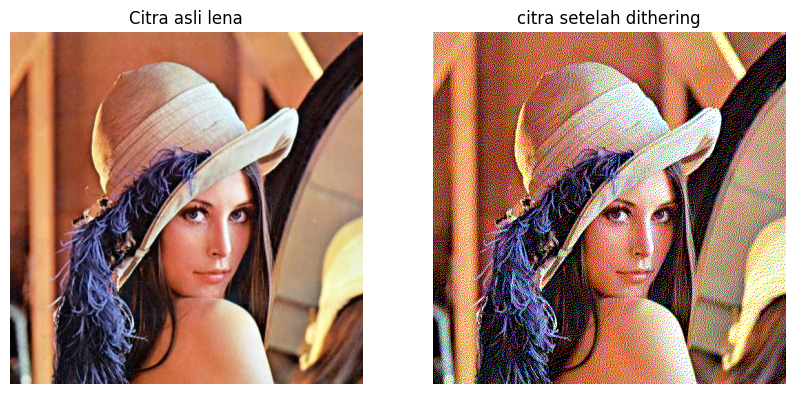

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg(gray, L=2):
    # 1. img = gray diubah ke float32
    img = gray.astype(np.float32).copy()

    # 2. step = 255 / (L - 1)
    step = 255.0 / (L - 1)

    # 3. H, W = tinggi, lebar citra
    H, W = img.shape

    # 4. Loop y dan x
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * 7/16

            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3/16

            if y + 1 < H:
                img[y + 1, x] += error * 5/16

            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1/16

    # 5. Batasi nilai img ke 0-255 lalu ubah ke uint8
    return np.clip(img, 0, 255).astype(np.uint8)

# Tahap 1: Verifikasi dengan citra contoh lena.jpg
bgr_lena = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena.jpg')
if bgr_lena is not None:
    # Karena citra berwarna, pisahkan kanal B, G, R
    b_lena, g_lena, r_lena = cv.split(bgr_lena)

    # Terapkan dithering pada masing-masing kanal (sesuai catatan di modul)
    b_dith = floyd_steinberg(b_lena, L=2)
    g_dith = floyd_steinberg(g_lena, L=2)
    r_dith = floyd_steinberg(r_lena, L=2)

    # Gabungkan kembali
    lena_dithered = cv.merge((b_dith, g_dith, r_dith))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(bgr_lena, cv.COLOR_BGR2RGB))
    plt.title("Citra asli lena")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(lena_dithered, cv.COLOR_BGR2RGB))
    plt.title("citra setelah dithering")
    plt.axis('off')

    plt.show()
else:
    print("lena.jpg tidak ditemukan.")

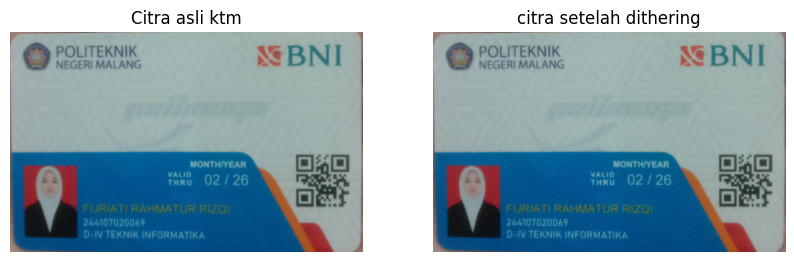

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg(gray, L=2):
    # 1. img = gray diubah ke float32
    img = gray.astype(np.float32).copy()

    # 2. step = 255 / (L - 1)
    step = 255.0 / (L - 1)

    # 3. H, W = tinggi, lebar citra
    H, W = img.shape

    # 4. Loop y dan x
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * 7/16

            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3/16

            if y + 1 < H:
                img[y + 1, x] += error * 5/16

            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1/16

    # 5. Batasi nilai img ke 0-255 lalu ubah ke uint8
    return np.clip(img, 0, 255).astype(np.uint8)

# Tahap 1: Verifikasi dengan citra contoh ktm.jpg
bgr_ktm = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/KTM-1B.jpeg')
if bgr_ktm is not None:
    # Karena citra berwarna, pisahkan kanal B, G, R
    b_ktm, g_ktm, r_ktm = cv.split(bgr_ktm)

    # Terapkan dithering pada masing-masing kanal (sesuai catatan di modul)
    b_dith = floyd_steinberg(b_ktm, L=2)
    g_dith = floyd_steinberg(g_ktm, L=2)
    r_dith = floyd_steinberg(r_ktm, L=2)

    # Gabungkan kembali
    ktm_dithered = cv.merge((b_dith, g_dith, r_dith))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(bgr_ktm, cv.COLOR_BGR2RGB))
    plt.title("Citra asli ktm")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(ktm_dithered, cv.COLOR_BGR2RGB))
    plt.title("citra setelah dithering")
    plt.axis('off')

    plt.show()
else:
    print("ktm.jpg tidak ditemukan.")

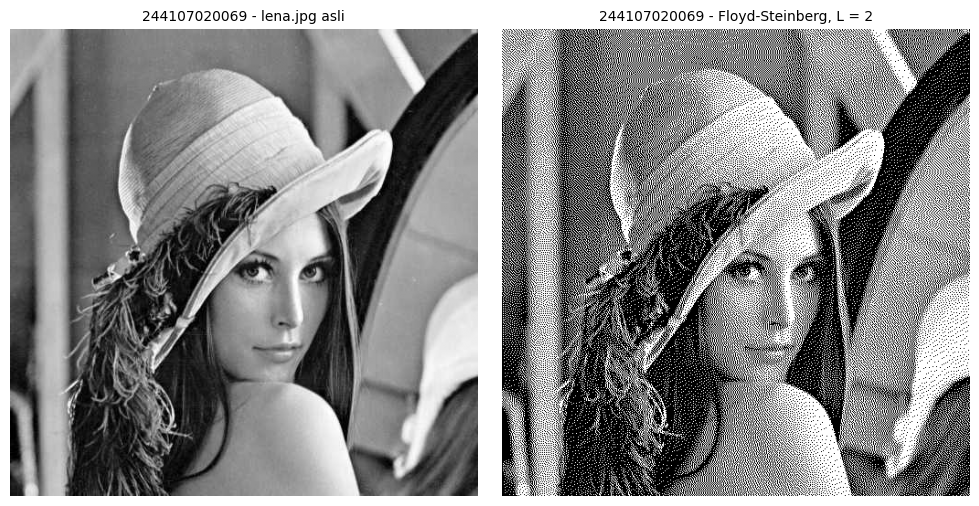

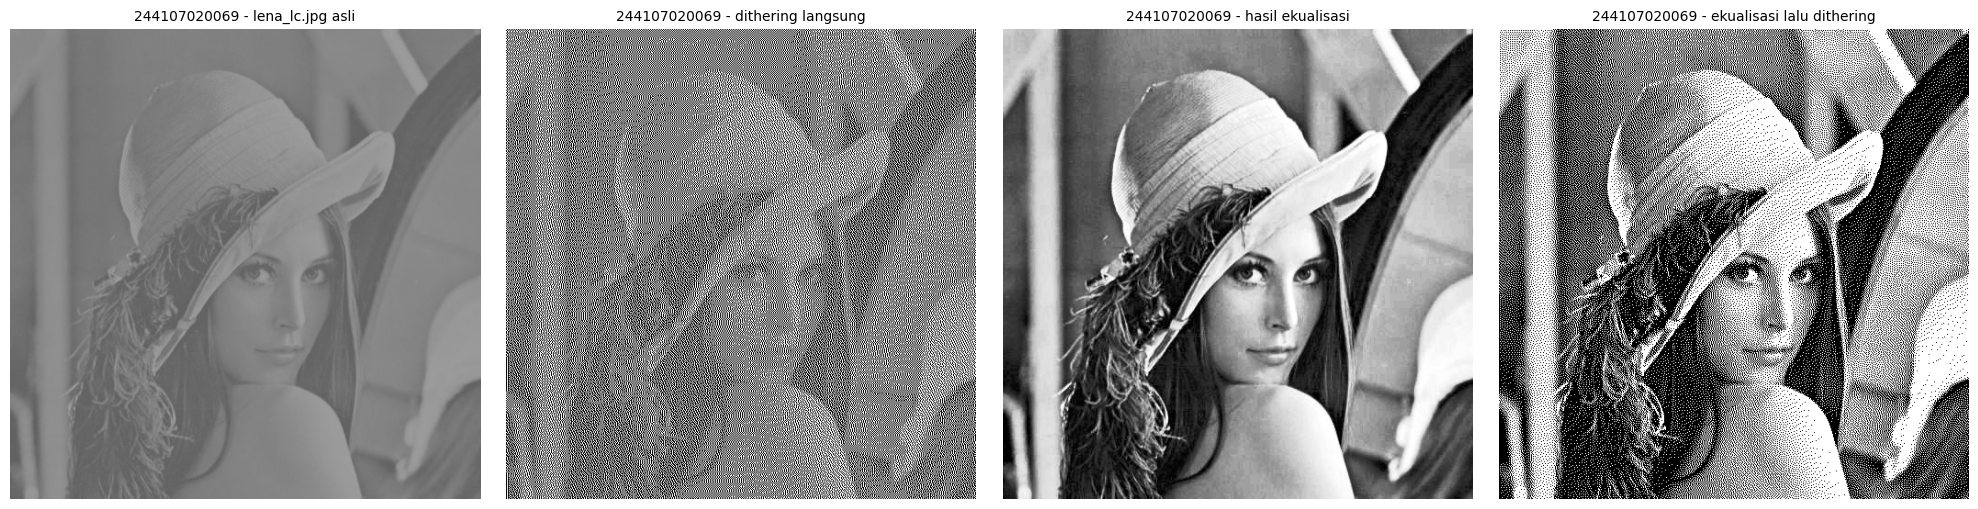

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            # Sebarkan error ke tetangga dengan pengecekan batas (boundary)
            if x + 1 < W:
                img[y, x + 1] += error * 7/16
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3/16
            if y + 1 < H:
                img[y + 1, x] += error * 5/16
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1/16

    return np.clip(img, 0, 255).astype(np.uint8)

# Konfigurasi Path dan NIM
NIM = "244107020069"
path_lena = '/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena.jpg'
path_lena_lc = '/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena_lc.jpg'

lena = cv2.imread(path_lena, cv2.IMREAD_GRAYSCALE)

if lena is not None:
    dither_lena = floyd_steinberg(lena, L=2)

    fig1, axes1 = plt.subplots(1, 2, figsize=(10, 5))

    axes1[0].imshow(lena, cmap="gray", vmin=0, vmax=255)
    axes1[0].set_title(f"{NIM} - lena.jpg asli", fontsize=10)
    axes1[0].axis("off")

    axes1[1].imshow(dither_lena, cmap="gray", vmin=0, vmax=255)
    axes1[1].set_title(f"{NIM} - Floyd-Steinberg, L = 2", fontsize=10)
    axes1[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Gambar tidak ditemukan di {path_lena}")
lena_lc = cv2.imread(path_lena_lc, cv2.IMREAD_GRAYSCALE)

if lena_lc is not None:
    # 1. Dithering langsung pada lena_lc
    dither_langsung = floyd_steinberg(lena_lc, L=2)

    # 2. Histogram Equalization pada lena_lc
    equalized = cv2.equalizeHist(lena_lc)

    # 3. Dithering pada hasil equalization
    dither_equalized = floyd_steinberg(equalized, L=2)

    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))

    axes2[0].imshow(lena_lc, cmap="gray", vmin=0, vmax=255)
    axes2[0].set_title(f"{NIM} - lena_lc.jpg asli", fontsize=10)
    axes2[0].axis("off")

    axes2[1].imshow(dither_langsung, cmap="gray", vmin=0, vmax=255)
    axes2[1].set_title(f"{NIM} - dithering langsung", fontsize=10)
    axes2[1].axis("off")

    axes2[2].imshow(equalized, cmap="gray", vmin=0, vmax=255)
    axes2[2].set_title(f"{NIM} - hasil ekualisasi", fontsize=10)
    axes2[2].axis("off")

    axes2[3].imshow(dither_equalized, cmap="gray", vmin=0, vmax=255)
    axes2[3].set_title(f"{NIM} - ekualisasi lalu dithering", fontsize=10)
    axes2[3].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Gambar tidak ditemukan di {path_lena_lc}")

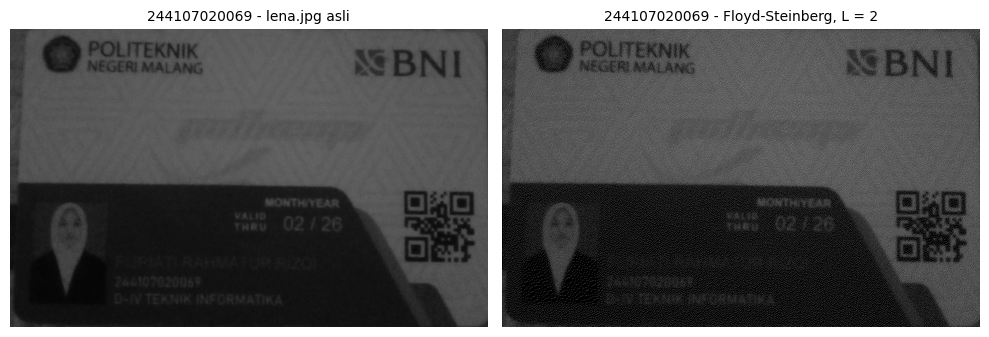

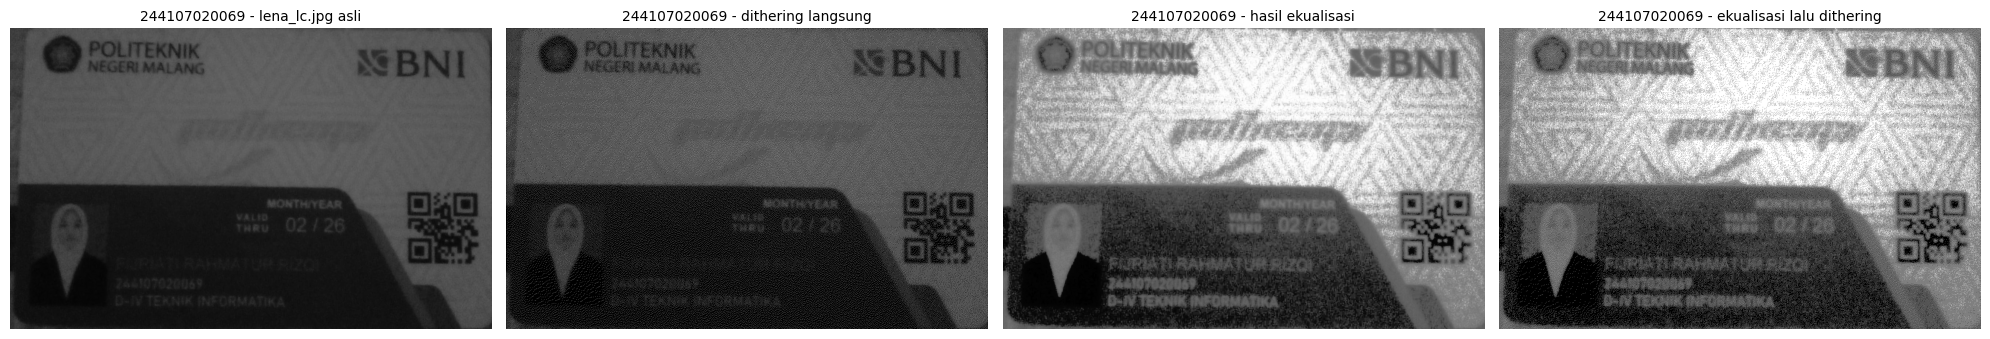

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            # Sebarkan error ke tetangga dengan pengecekan batas (boundary)
            if x + 1 < W:
                img[y, x + 1] += error * 7/16
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3/16
            if y + 1 < H:
                img[y + 1, x] += error * 5/16
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1/16

    return np.clip(img, 0, 255).astype(np.uint8)

# Konfigurasi Path dan NIM
NIM = "244107020069"
path_lena = '/content/drive/MyDrive/TI 3C RESOURCES /PCVK/KTM-1A.jpeg'
path_lena_lc = '/content/drive/MyDrive/TI 3C RESOURCES /PCVK/KTM-1A.jpeg'

lena = cv2.imread(path_lena, cv2.IMREAD_GRAYSCALE)

if lena is not None:
    dither_lena = floyd_steinberg(lena, L=2)

    fig1, axes1 = plt.subplots(1, 2, figsize=(10, 5))

    axes1[0].imshow(lena, cmap="gray", vmin=0, vmax=255)
    axes1[0].set_title(f"{NIM} - lena.jpg asli", fontsize=10)
    axes1[0].axis("off")

    axes1[1].imshow(dither_lena, cmap="gray", vmin=0, vmax=255)
    axes1[1].set_title(f"{NIM} - Floyd-Steinberg, L = 2", fontsize=10)
    axes1[1].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Gambar tidak ditemukan di {path_lena}")
lena_lc = cv2.imread(path_lena_lc, cv2.IMREAD_GRAYSCALE)

if lena_lc is not None:
    # 1. Dithering langsung pada lena_lc
    dither_langsung = floyd_steinberg(lena_lc, L=2)

    # 2. Histogram Equalization pada lena_lc
    equalized = cv2.equalizeHist(lena_lc)

    # 3. Dithering pada hasil equalization
    dither_equalized = floyd_steinberg(equalized, L=2)

    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))

    axes2[0].imshow(lena_lc, cmap="gray", vmin=0, vmax=255)
    axes2[0].set_title(f"{NIM} - lena_lc.jpg asli", fontsize=10)
    axes2[0].axis("off")

    axes2[1].imshow(dither_langsung, cmap="gray", vmin=0, vmax=255)
    axes2[1].set_title(f"{NIM} - dithering langsung", fontsize=10)
    axes2[1].axis("off")

    axes2[2].imshow(equalized, cmap="gray", vmin=0, vmax=255)
    axes2[2].set_title(f"{NIM} - hasil ekualisasi", fontsize=10)
    axes2[2].axis("off")

    axes2[3].imshow(dither_equalized, cmap="gray", vmin=0, vmax=255)
    axes2[3].set_title(f"{NIM} - ekualisasi lalu dithering", fontsize=10)
    axes2[3].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Gambar tidak ditemukan di {path_lena_lc}")